In [1]:
from qiskit import QuantumCircuit

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def create_fixed_tfim_circuit(n, layers=2, theta_zz=0.35, theta_x=0.45):
    """
    Fixed-depth 1D transverse-field Ising-style circuit.

    This is NOT variational:
    - no optimizer
    - no parameter sweep
    - one fixed circuit per n
    """

    qc = QuantumCircuit(n)

    # Start from |+...+>
    qc.h(range(n))

    for _ in range(layers):
        # Even ZZ bonds
        for i in range(0, n - 1, 2):
            qc.rzz(theta_zz, i, i + 1)

        # Odd ZZ bonds
        for i in range(1, n - 1, 2):
            qc.rzz(theta_zz, i, i + 1)

        # Transverse field rotations
        for i in range(n):
            qc.rx(theta_x, i)

    return qc

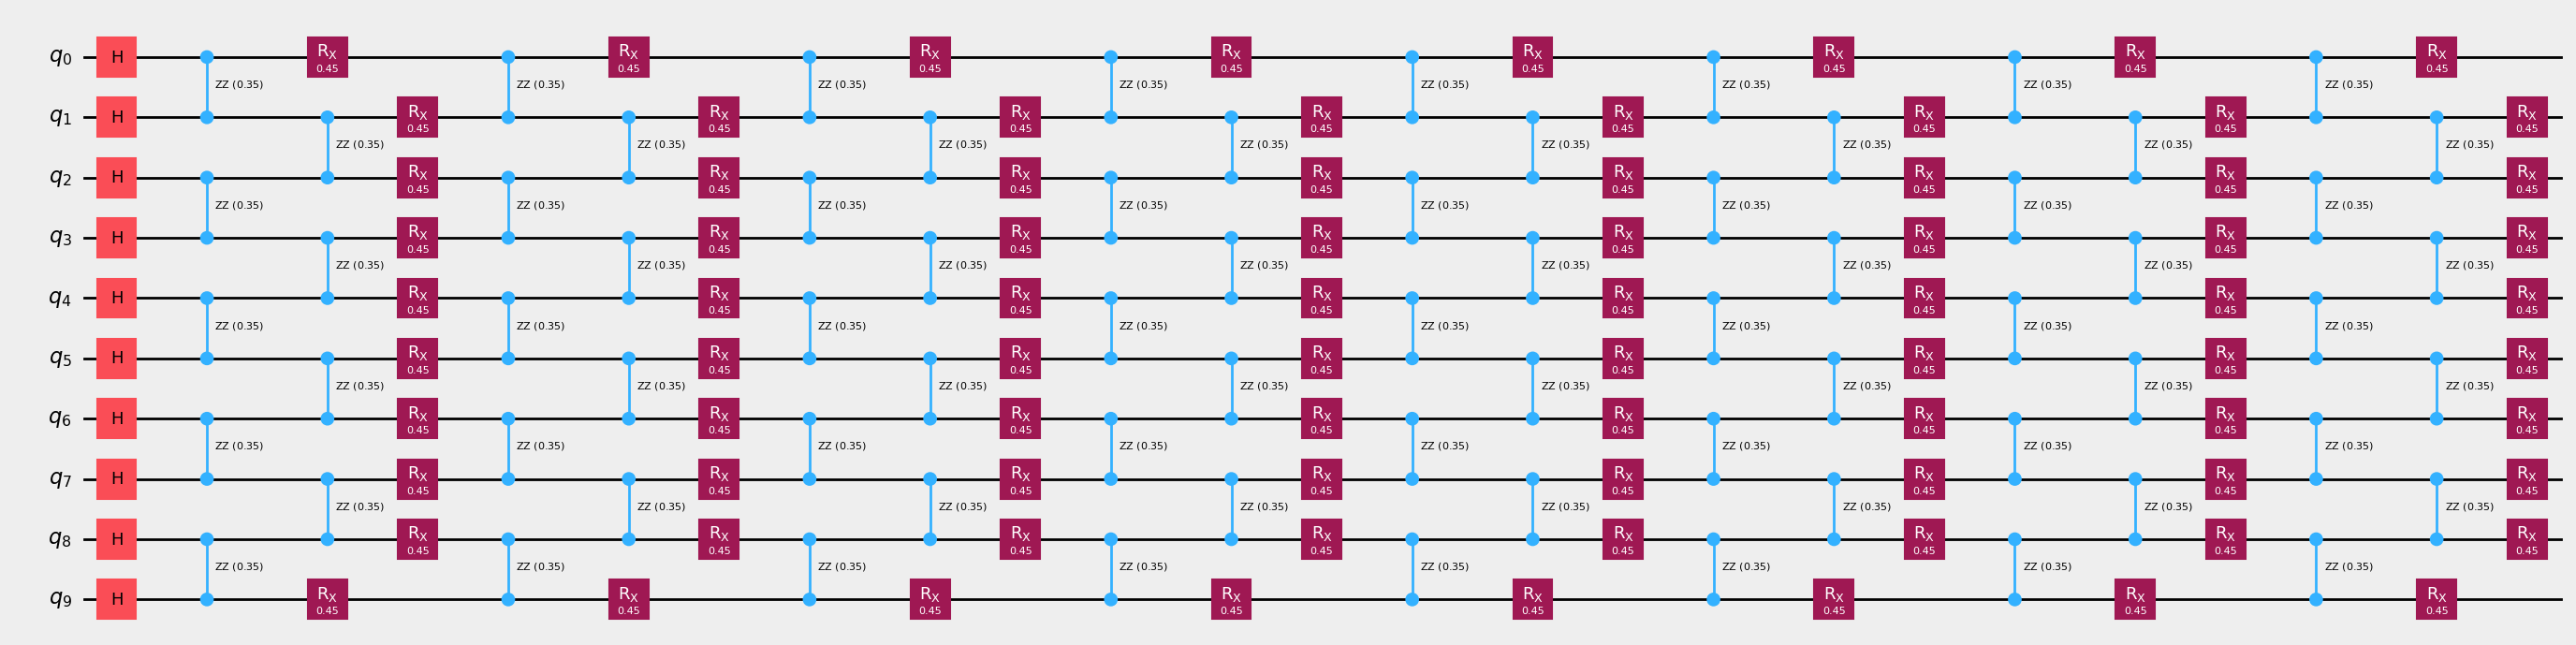

In [3]:
tfim_layers = 8
theta_zz = 0.35
theta_x = 0.45
n = 10

circuit = create_fixed_tfim_circuit(
    n=n,
    layers=tfim_layers,
    theta_zz=theta_zz,
    theta_x=theta_x,
)

circuit.draw("mpl", style={"backgroundcolor": "#EEEEEE"}, fold=-1)

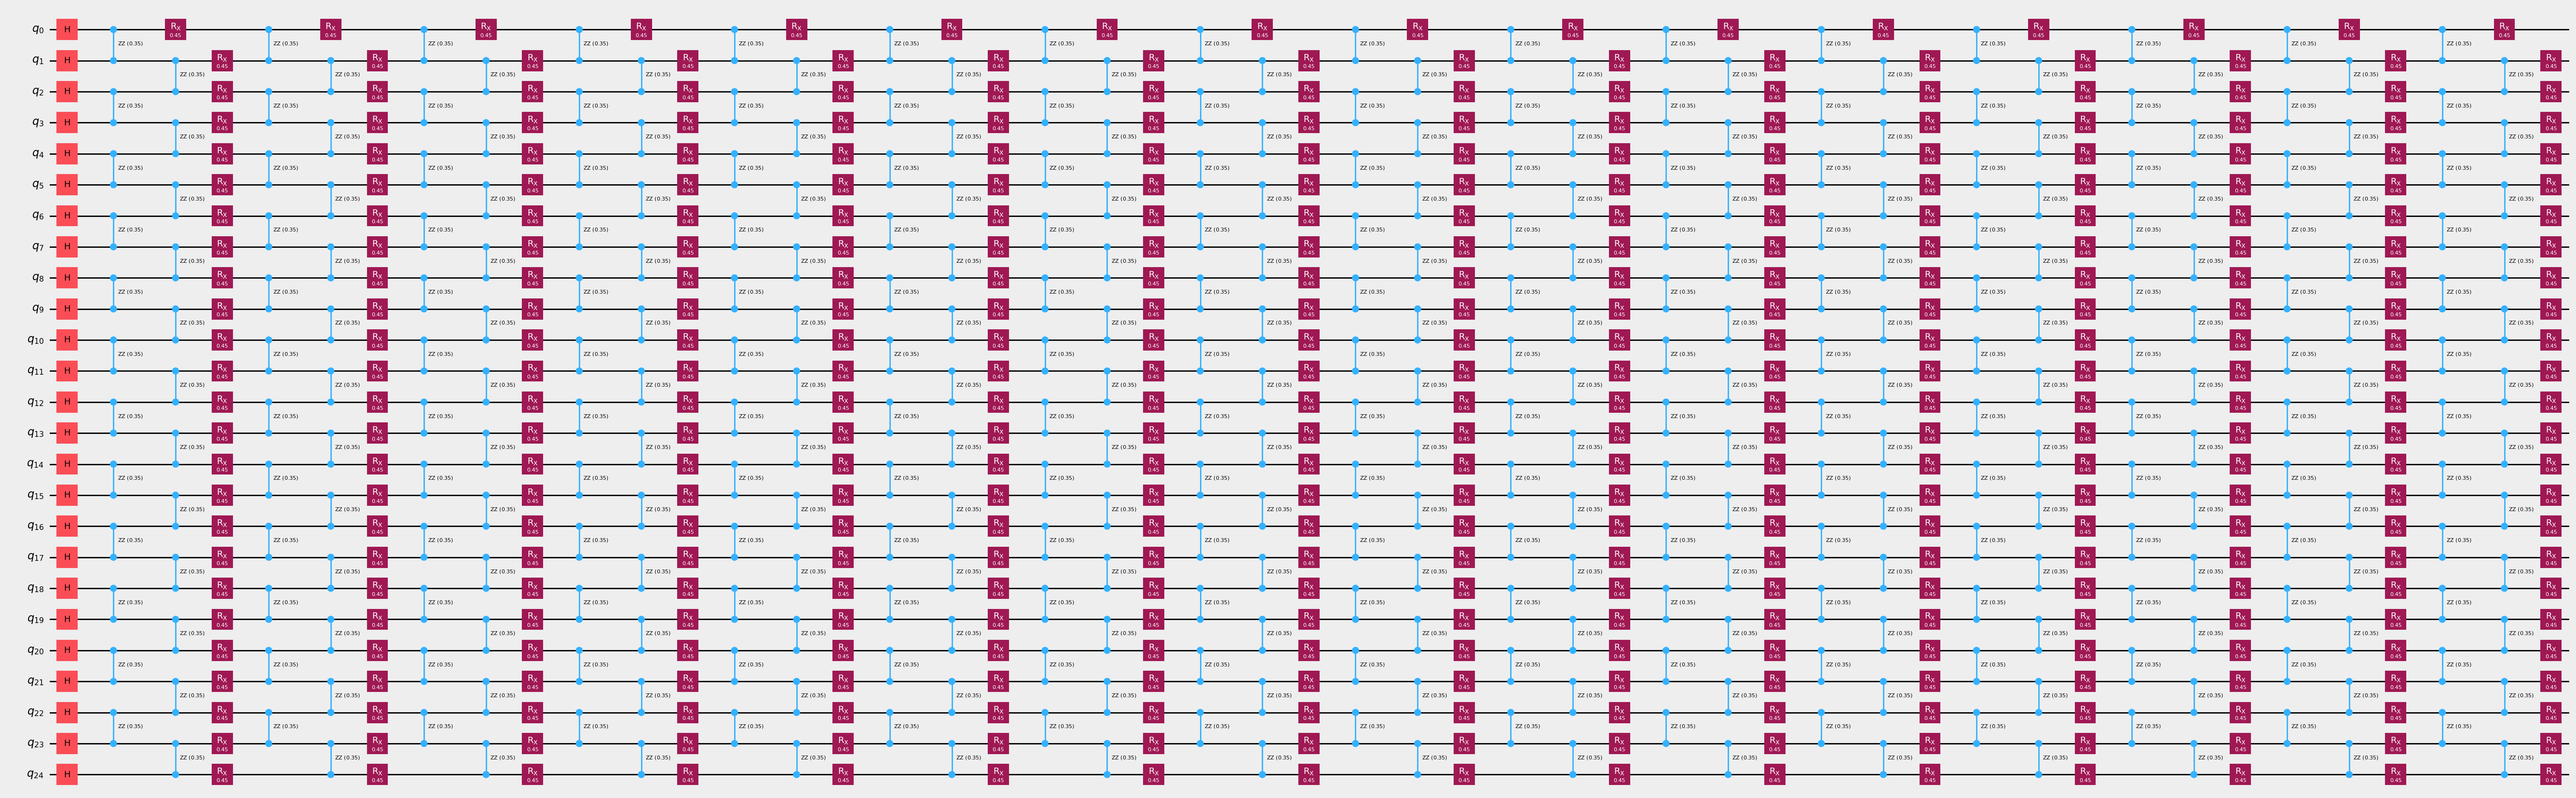

In [4]:
tfim_layers = 16
theta_zz = 0.35
theta_x = 0.45
n = 25

circuit = create_fixed_tfim_circuit(
    n=n,
    layers=tfim_layers,
    theta_zz=theta_zz,
    theta_x=theta_x,
)

circuit.draw("mpl", style={"backgroundcolor": "#EEEEEE"}, fold=-1)

Loaded clean results from: results\tfim_probe-16layers-full-chain\tfim_probe_results_no_MZ.csv
Loaded clean summary from: results\tfim_probe-16layers-full-chain\tfim_probe_summary_no_MZ.csv
Observables found: ['MX_full', 'ZZ_full']
Providers found: ['IBM TREX + twirling', 'IBM raw', 'Q-CTRL']
n values found: [np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(125)]

QPU seconds available in summary_df:
provider  IBM TREX + twirling    IBM raw  Q-CTRL
n                                               
25                  40.938803  19.196573    28.0
50                  40.938803  19.196573    28.0
75                  40.938803  19.196573    28.0
100                 40.938803  19.196573    28.0
125                 40.938803  19.196573    28.0

Provider order used: ['IBM raw', 'IBM TREX + twirling', 'Q-CTRL']


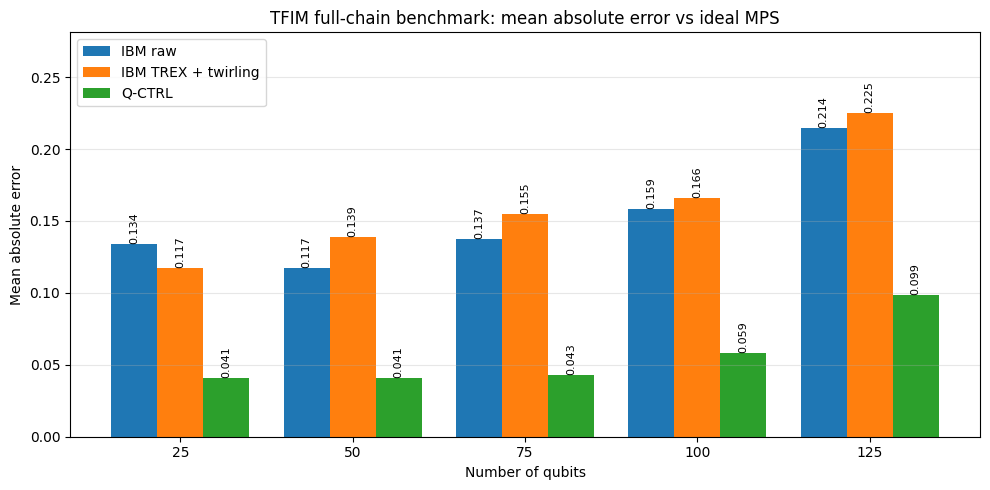

Saved plot: results\tfim_probe-16layers-full-chain\plots\mean_absolute_error_vs_ideal_mps.png


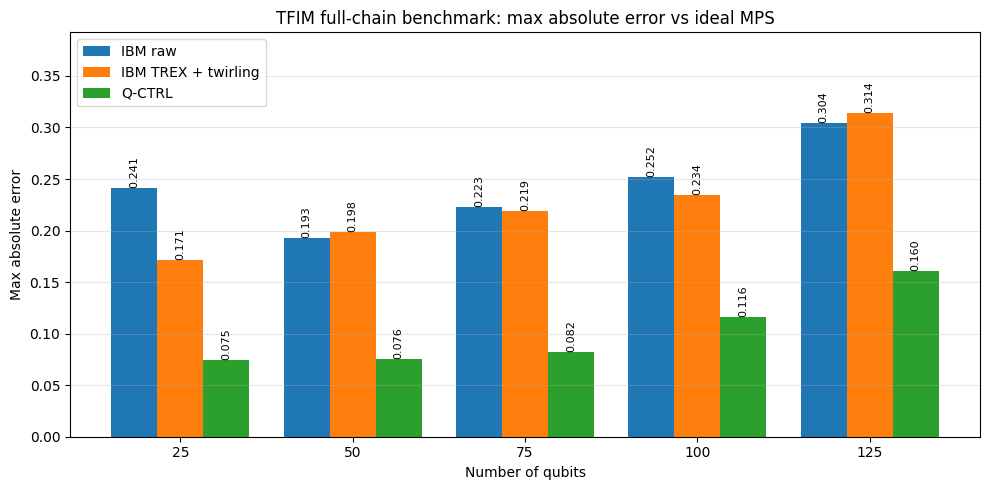

Saved plot: results\tfim_probe-16layers-full-chain\plots\max_absolute_error_vs_ideal_mps.png


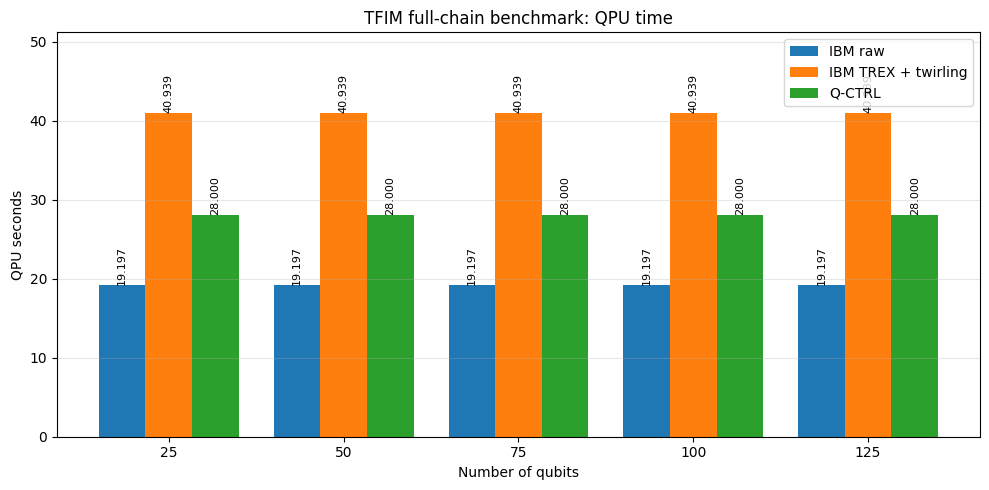

Saved plot: results\tfim_probe-16layers-full-chain\plots\qpu_seconds.png


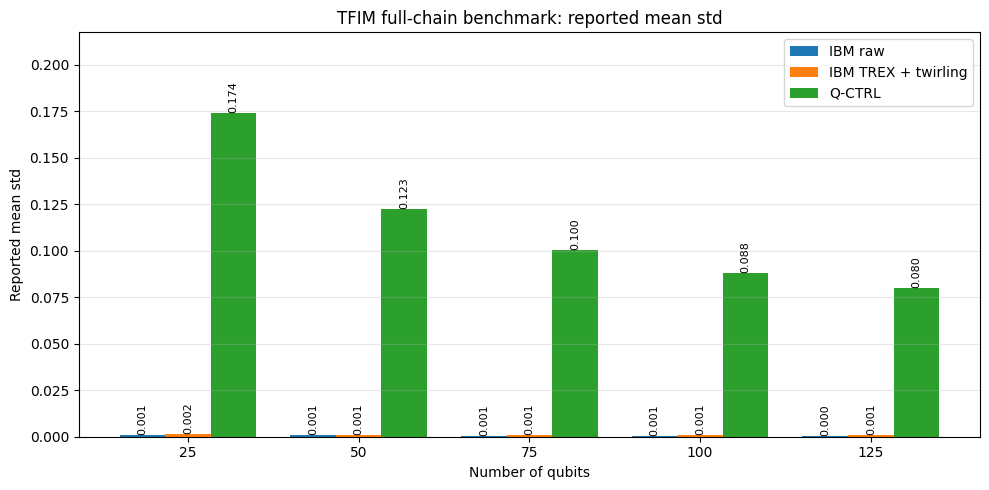

Saved plot: results\tfim_probe-16layers-full-chain\plots\reported_mean_std.png


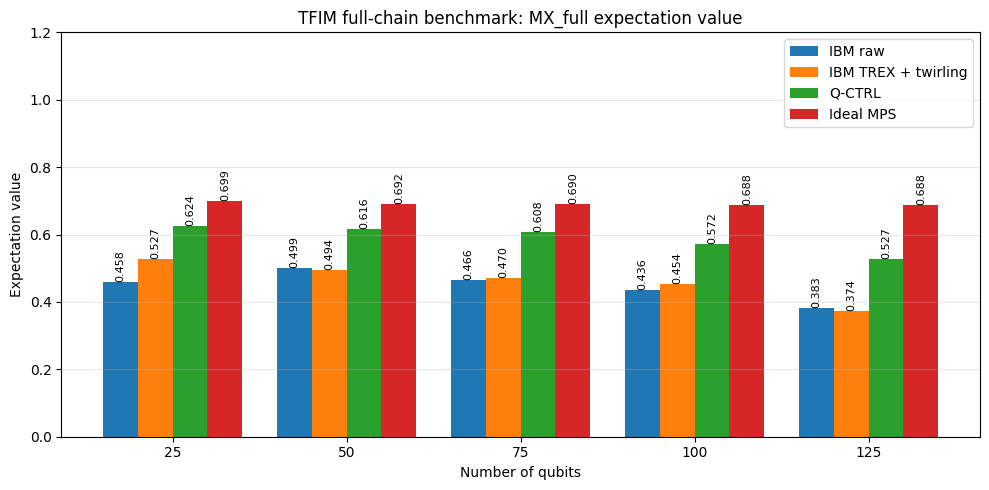

Saved plot: results\tfim_probe-16layers-full-chain\plots\MX_full_expectation_value.png


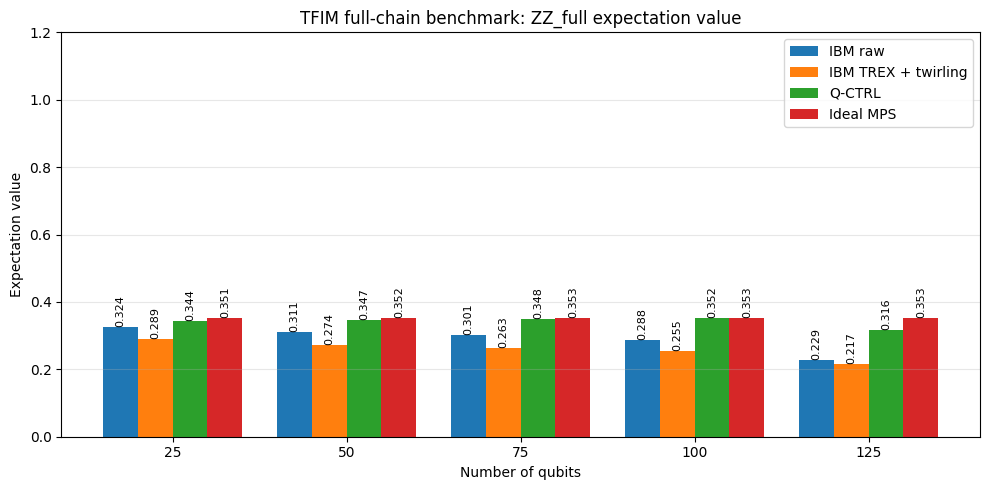

Saved plot: results\tfim_probe-16layers-full-chain\plots\ZZ_full_expectation_value.png


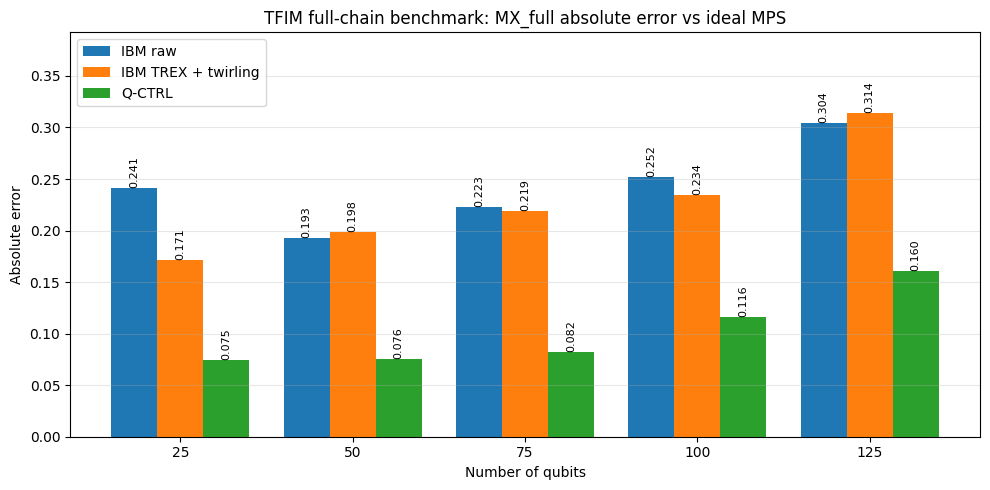

Saved plot: results\tfim_probe-16layers-full-chain\plots\MX_full_absolute_error.png


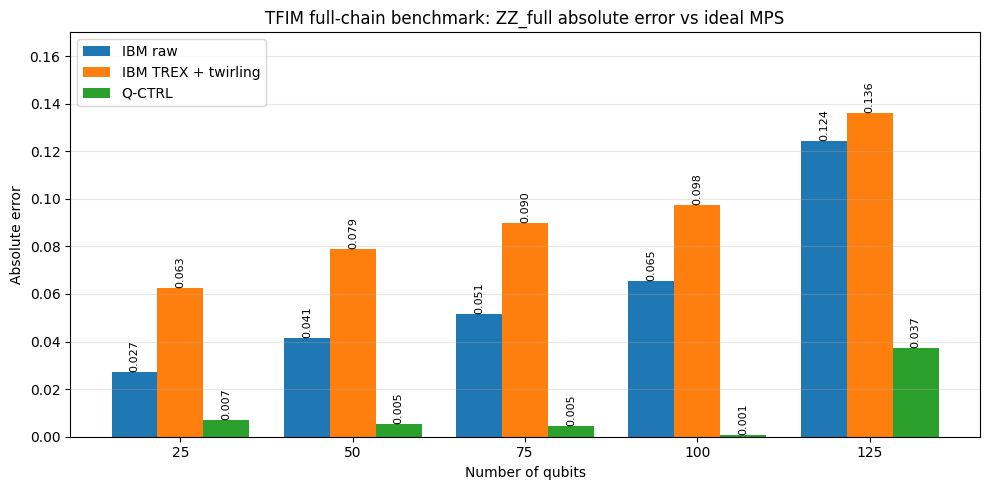

Saved plot: results\tfim_probe-16layers-full-chain\plots\ZZ_full_absolute_error.png
Done.
Plots saved in: results\tfim_probe-16layers-full-chain\plots


In [5]:



# ============================================================
# Paths
# ============================================================

RESULT_DIR = Path("results/tfim_probe-16layers-full-chain")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_RESULTS_CSV = RESULT_DIR / "tfim_probe_results_no_MZ.csv"
CLEAN_SUMMARY_CSV = RESULT_DIR / "tfim_probe_summary_no_MZ.csv"


# ============================================================
# Load no-MZ CSVs directly
# IMPORTANT: this cell does not recompute or overwrite them
# ============================================================

tfim_df = pd.read_csv(CLEAN_RESULTS_CSV)
summary_df = pd.read_csv(CLEAN_SUMMARY_CSV)

tfim_df["n"] = pd.to_numeric(tfim_df["n"], errors="coerce")
summary_df["n"] = pd.to_numeric(summary_df["n"], errors="coerce")


# ============================================================
# Sanity checks
# ============================================================

check_mz = tfim_df["observable"].astype(str).str.upper().str.match(r"^MZ($|_)")
assert not check_mz.any(), "MZ is still present in tfim_df."

print("Loaded clean results from:", CLEAN_RESULTS_CSV)
print("Loaded clean summary from:", CLEAN_SUMMARY_CSV)
print("Observables found:", sorted(tfim_df["observable"].unique()))
print("Providers found:", sorted(tfim_df["provider"].unique()))
print("n values found:", sorted(tfim_df["n"].dropna().unique()))

if "qpu_seconds" in summary_df.columns:
    print("\nQPU seconds available in summary_df:")
    print(
        summary_df
        .pivot_table(
            index="n",
            columns="provider",
            values="qpu_seconds",
            aggfunc="mean",
        )
    )
else:
    print("\nWARNING: qpu_seconds column not found in summary_df.")
    print("Columns in summary_df:", list(summary_df.columns))


# ============================================================
# Ideal MPS expected values
# These are added as an extra bar column in expectation plots
# ============================================================

mps_reference = {
    25:  {"MX_full": 0.69898296, "ZZ_full": 0.35147878},
    50:  {"MX_full": 0.69193275, "ZZ_full": 0.35236537},
    75:  {"MX_full": 0.68958268, "ZZ_full": 0.35265292},
    100: {"MX_full": 0.68840764, "ZZ_full": 0.35279524},
    125: {"MX_full": 0.68770262, "ZZ_full": 0.35288017},
}

mps_ref_df = (
    pd.DataFrame.from_dict(mps_reference, orient="index")
    .reset_index()
    .rename(columns={"index": "n"})
    .melt(
        id_vars="n",
        var_name="observable",
        value_name="Ideal MPS",
    )
)

mps_ref_df["n"] = pd.to_numeric(mps_ref_df["n"], errors="coerce")
mps_ref_df["observable_key"] = mps_ref_df["observable"].astype(str).str.upper()


# ============================================================
# Title prefix
# ============================================================

mode_suffix = (
    "full-chain"
    if tfim_df["observable"].astype(str).str.endswith("_full").any()
    else "probe"
)

benchmark_title_prefix = f"TFIM {mode_suffix} benchmark"


# ============================================================
# Provider order
# ============================================================

provider_order = [
    p for p in [
        "IBM raw",
        "IBM TREX + twirling",
        "IBM ZNE",
        "Q-CTRL",
        "QESEM",
    ]
    if p in tfim_df["provider"].unique() or p in summary_df["provider"].unique()
]

print("\nProvider order used:", provider_order)


# ============================================================
# Helper functions
# ============================================================

def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_")


def finite_ymax(plot_df, exclude_col="n", default=0.1):
    value_cols = [c for c in plot_df.columns if c != exclude_col]

    if len(value_cols) == 0:
        return default

    values = plot_df[value_cols].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]

    if finite.size == 0:
        return default

    return np.nanmax(finite)


def finite_ymin(plot_df, exclude_col="n", default=0.0):
    value_cols = [c for c in plot_df.columns if c != exclude_col]

    if len(value_cols) == 0:
        return default

    values = plot_df[value_cols].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]

    if finite.size == 0:
        return default

    return np.nanmin(finite)


def grouped_bar(
    plot_df,
    x_col,
    series_cols,
    title,
    ylabel,
    xlabel,
    filename,
    ylim=None,
):
    series_cols = [col for col in series_cols if col in plot_df.columns]

    x_labels = plot_df[x_col].astype(str).tolist()
    x = np.arange(len(plot_df))

    width = 0.8 / max(len(series_cols), 1)

    plt.figure(figsize=(10, 5))

    for i, col in enumerate(series_cols):
        offset = (i - (len(series_cols) - 1) / 2) * width
        y = plot_df[col].astype(float).values

        bars = plt.bar(
            x + offset,
            y,
            width,
            label=col,
        )

        for bar, value in zip(bars, y):
            if np.isfinite(value):
                va = "bottom" if value >= 0 else "top"

                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.3f}",
                    ha="center",
                    va=va,
                    fontsize=8,
                    rotation=90,
                )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x, x_labels)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot:", filename)


def provider_pivot(df, value_col):
    plot_df = (
        df.pivot_table(
            index="n",
            columns="provider",
            values=value_col,
            aggfunc="mean",
        )
        .reset_index()
    )

    cols = ["n"] + [p for p in provider_order if p in plot_df.columns]

    return plot_df[cols]


# ============================================================
# Plot 1: Mean absolute error
# ============================================================

plot_df = provider_pivot(summary_df, "mean_absolute_error")
ymax = finite_ymax(plot_df)

grouped_bar(
    plot_df=plot_df,
    x_col="n",
    series_cols=provider_order,
    title=f"{benchmark_title_prefix}: mean absolute error vs ideal MPS",
    ylabel="Mean absolute error",
    xlabel="Number of qubits",
    filename=PLOT_DIR / "mean_absolute_error_vs_ideal_mps.png",
    ylim=(0, max(0.1, ymax * 1.25)),
)


# ============================================================
# Plot 2: Max absolute error
# ============================================================

plot_df = provider_pivot(summary_df, "max_absolute_error")
ymax = finite_ymax(plot_df)

grouped_bar(
    plot_df=plot_df,
    x_col="n",
    series_cols=provider_order,
    title=f"{benchmark_title_prefix}: max absolute error vs ideal MPS",
    ylabel="Max absolute error",
    xlabel="Number of qubits",
    filename=PLOT_DIR / "max_absolute_error_vs_ideal_mps.png",
    ylim=(0, max(0.1, ymax * 1.25)),
)


# ============================================================
# Plot 3: QPU seconds
# This now uses qpu_seconds already present in no-MZ summary_df
# ============================================================

if "qpu_seconds" in summary_df.columns:
    qpu_summary_df = summary_df.dropna(subset=["qpu_seconds"]).copy()

    if not qpu_summary_df.empty:
        plot_df = provider_pivot(qpu_summary_df, "qpu_seconds")
        ymax = finite_ymax(plot_df, default=1)

        grouped_bar(
            plot_df=plot_df,
            x_col="n",
            series_cols=provider_order,
            title=f"{benchmark_title_prefix}: QPU time",
            ylabel="QPU seconds",
            xlabel="Number of qubits",
            filename=PLOT_DIR / "qpu_seconds.png",
            ylim=(0, max(1, ymax * 1.25)),
        )
    else:
        print("Skipping QPU time plot: qpu_seconds exists but all values are NaN.")
else:
    print("Skipping QPU time plot: qpu_seconds column not found.")


# ============================================================
# Plot 4: Reported standard deviation
# ============================================================

if "mean_std" in summary_df.columns:
    plot_df = provider_pivot(summary_df, "mean_std")
    ymax = finite_ymax(plot_df)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=provider_order,
        title=f"{benchmark_title_prefix}: reported mean std",
        ylabel="Reported mean std",
        xlabel="Number of qubits",
        filename=PLOT_DIR / "reported_mean_std.png",
        ylim=(0, max(0.1, ymax * 1.25)),
    )
else:
    print("Skipping reported std plot: mean_std column not found.")


# ============================================================
# Plot 5: Per-observable expectation values
# Ideal MPS is added as another bar column
# ============================================================

for obs in sorted(tfim_df["observable"].unique()):
    subset = tfim_df[tfim_df["observable"] == obs].copy()

    plot_df = (
        subset
        .pivot_table(
            index="n",
            columns="provider",
            values="expectation_value",
            aggfunc="mean",
        )
        .reset_index()
    )

    obs_key = str(obs).upper()

    mps_obs_ref = (
        mps_ref_df[mps_ref_df["observable_key"] == obs_key]
        [["n", "Ideal MPS"]]
        .copy()
    )

    if not mps_obs_ref.empty:
        plot_df = plot_df.merge(
            mps_obs_ref,
            on="n",
            how="left",
        )

    expectation_series_cols = provider_order.copy()

    if "Ideal MPS" in plot_df.columns:
        expectation_series_cols.append("Ideal MPS")

    cols = ["n"] + [p for p in expectation_series_cols if p in plot_df.columns]
    plot_df = plot_df[cols]

    ymax = finite_ymax(plot_df, default=1.0)
    ymin = finite_ymin(plot_df, default=0.0)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=expectation_series_cols,
        title=f"{benchmark_title_prefix}: {obs} expectation value",
        ylabel="Expectation value",
        xlabel="Number of qubits",
        filename=PLOT_DIR / f"{safe_filename(obs)}_expectation_value.png",
        ylim=(min(0, ymin * 1.1), max(1.2, ymax * 1.1)),
    )


# ============================================================
# Plot 6: Per-observable absolute errors
# These are already errors relative to Ideal MPS
# ============================================================

for obs in sorted(tfim_df["observable"].unique()):
    subset = tfim_df[tfim_df["observable"] == obs].copy()

    plot_df = (
        subset
        .pivot_table(
            index="n",
            columns="provider",
            values="absolute_error",
            aggfunc="mean",
        )
        .reset_index()
    )

    cols = ["n"] + [p for p in provider_order if p in plot_df.columns]
    plot_df = plot_df[cols]

    ymax = finite_ymax(plot_df)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=provider_order,
        title=f"{benchmark_title_prefix}: {obs} absolute error vs ideal MPS",
        ylabel="Absolute error",
        xlabel="Number of qubits",
        filename=PLOT_DIR / f"{safe_filename(obs)}_absolute_error.png",
        ylim=(0, max(0.1, ymax * 1.25)),
    )


print("Done.")
print("Plots saved in:", PLOT_DIR)

Loaded clean results from: results\tfim_probe\tfim_probe_results_no_MZ.csv
Loaded clean summary from: results\tfim_probe\tfim_probe_summary_no_MZ.csv
Observables found: ['MX_full', 'ZZ_full']
Providers found: ['IBM TREX + twirling', 'IBM raw', 'Q-CTRL', 'QESEM']
n values found: [np.int64(25), np.int64(50), np.int64(75)]

QPU seconds available in summary_df:
provider  IBM TREX + twirling    IBM raw  Q-CTRL  QESEM
n                                                      
25                  28.000000  17.823486    28.0  271.0
50                  37.826296  17.823486    28.0  311.0
75                  37.826296  17.823486    28.0  211.0

Provider order used: ['IBM raw', 'IBM TREX + twirling', 'Q-CTRL', 'QESEM']


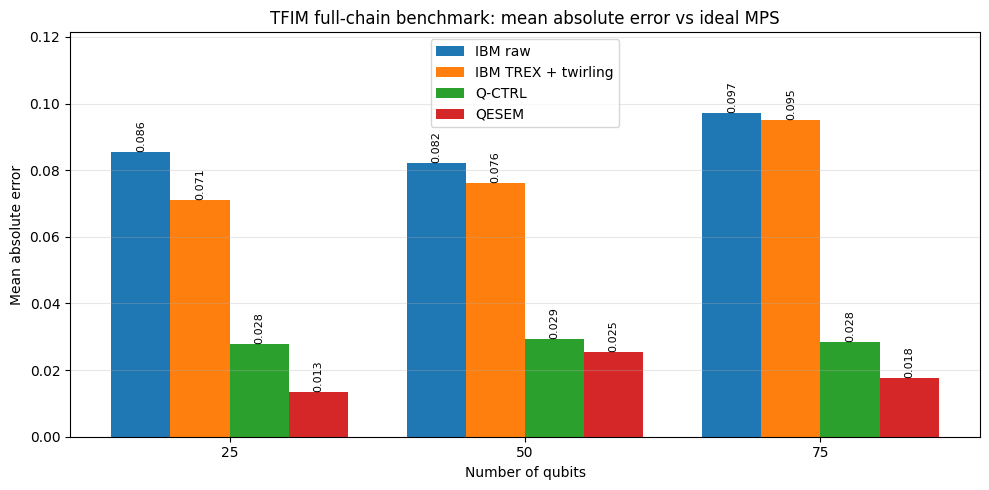

Saved plot: results\tfim_probe\plots\mean_absolute_error_vs_ideal_mps.png


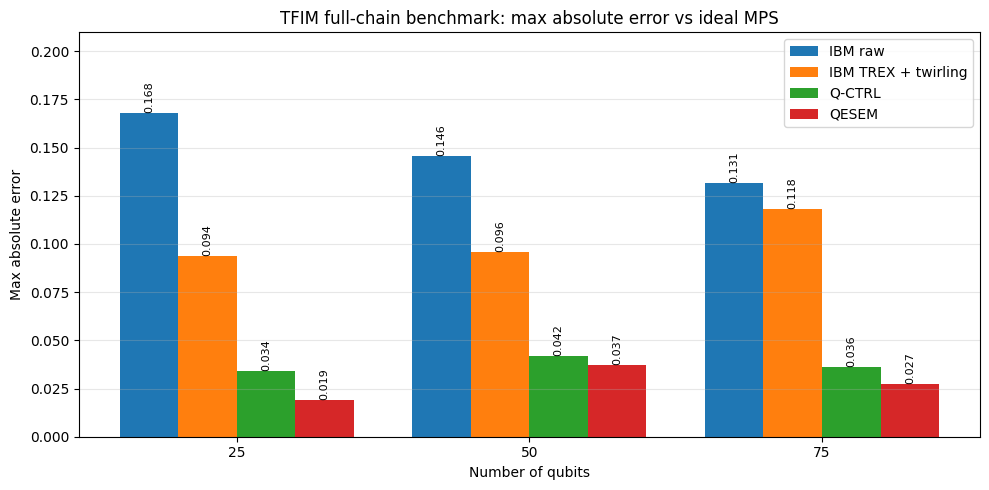

Saved plot: results\tfim_probe\plots\max_absolute_error_vs_ideal_mps.png


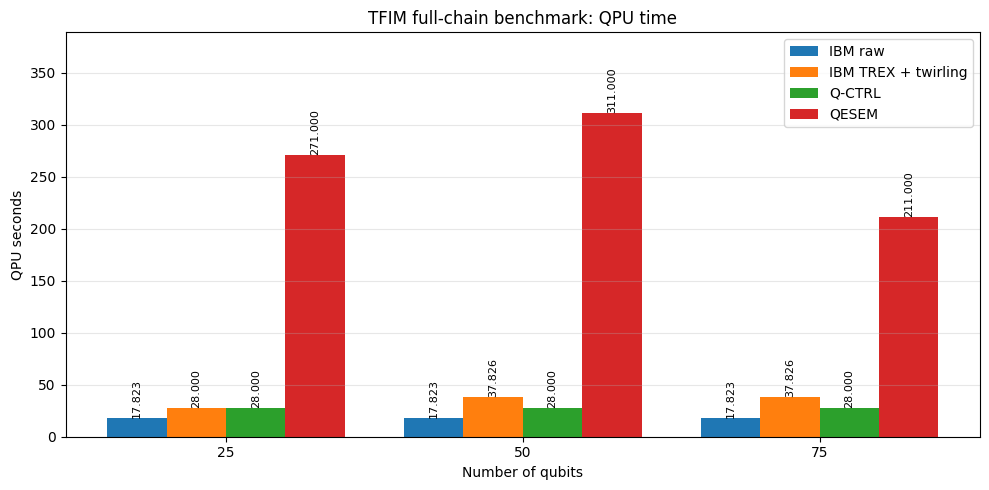

Saved plot: results\tfim_probe\plots\qpu_seconds.png


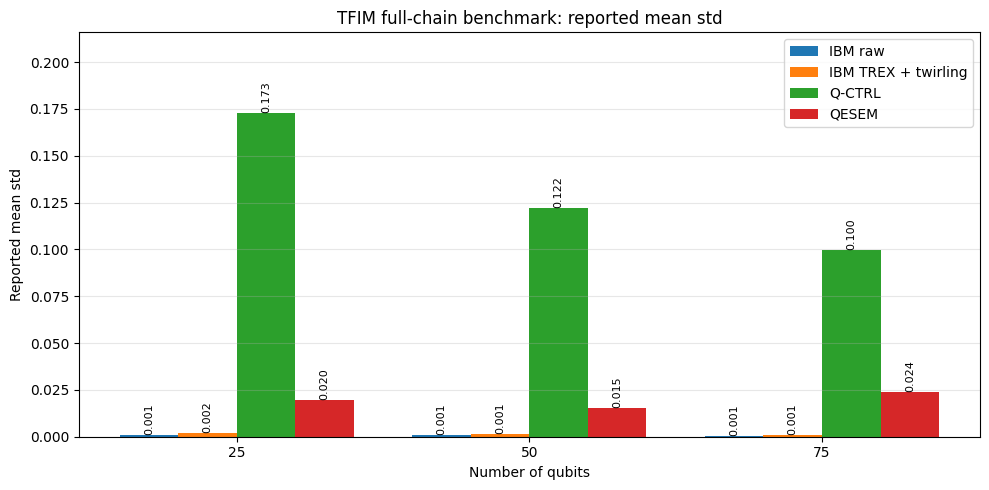

Saved plot: results\tfim_probe\plots\reported_mean_std.png


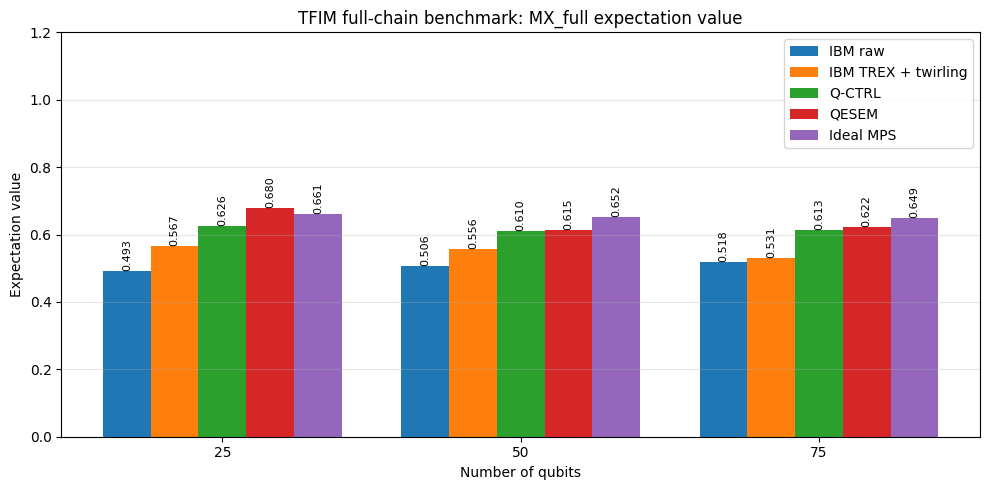

Saved plot: results\tfim_probe\plots\MX_full_expectation_value.png


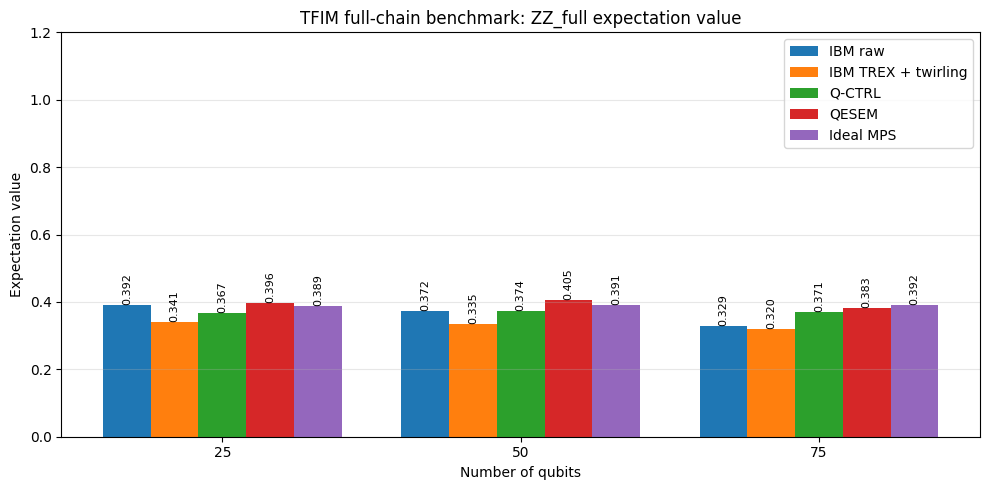

Saved plot: results\tfim_probe\plots\ZZ_full_expectation_value.png


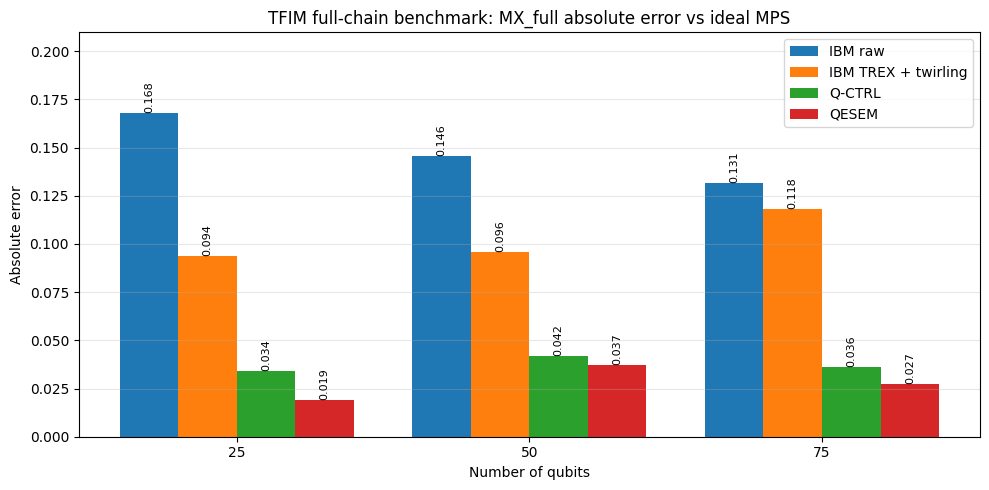

Saved plot: results\tfim_probe\plots\MX_full_absolute_error.png


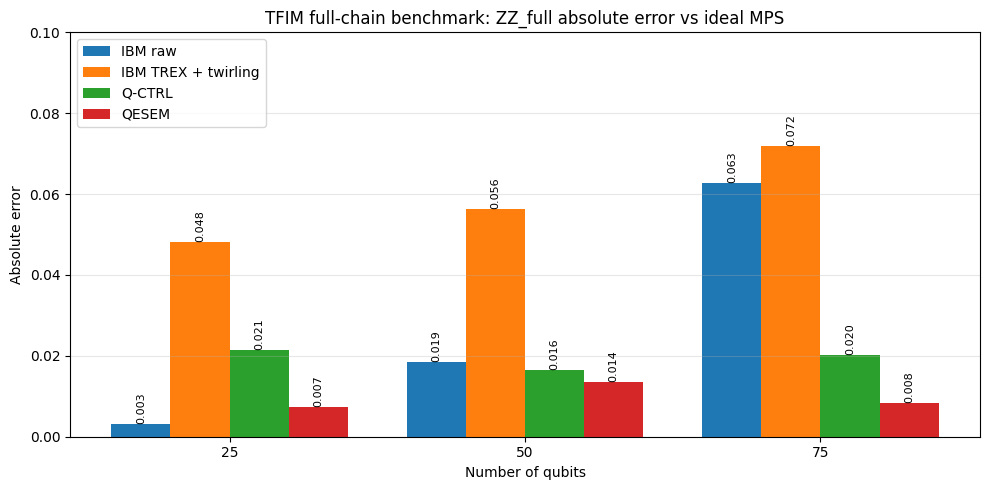

Saved plot: results\tfim_probe\plots\ZZ_full_absolute_error.png
Done.
Plots saved in: results\tfim_probe\plots


In [6]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

RESULT_DIR = Path("results/tfim_probe")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_RESULTS_CSV = RESULT_DIR / "tfim_probe_results_no_MZ.csv"
CLEAN_SUMMARY_CSV = RESULT_DIR / "tfim_probe_summary_no_MZ.csv"


# ============================================================
# Load no-MZ CSVs directly
# IMPORTANT: this cell does not recompute or overwrite them
# ============================================================

tfim_df = pd.read_csv(CLEAN_RESULTS_CSV)
summary_df = pd.read_csv(CLEAN_SUMMARY_CSV)

tfim_df["n"] = pd.to_numeric(tfim_df["n"], errors="coerce")
summary_df["n"] = pd.to_numeric(summary_df["n"], errors="coerce")


# ============================================================
# Sanity checks
# ============================================================

check_mz = tfim_df["observable"].astype(str).str.upper().str.match(r"^MZ($|_)")
assert not check_mz.any(), "MZ is still present in tfim_df."

print("Loaded clean results from:", CLEAN_RESULTS_CSV)
print("Loaded clean summary from:", CLEAN_SUMMARY_CSV)
print("Observables found:", sorted(tfim_df["observable"].unique()))
print("Providers found:", sorted(tfim_df["provider"].unique()))
print("n values found:", sorted(tfim_df["n"].dropna().unique()))

if "qpu_seconds" in summary_df.columns:
    print("\nQPU seconds available in summary_df:")
    print(
        summary_df
        .pivot_table(
            index="n",
            columns="provider",
            values="qpu_seconds",
            aggfunc="mean",
        )
    )
else:
    print("\nWARNING: qpu_seconds column not found in summary_df.")
    print("Columns in summary_df:", list(summary_df.columns))


# ============================================================
# Ideal MPS expected values
# These are added as an extra bar column in expectation plots
# ============================================================

mps_reference = {
    25:  {"MX_full": 0.66063421, "ZZ_full": 0.38867674},
    50:  {"MX_full": 0.65197805, "ZZ_full": 0.39098874},
    75:  {"MX_full": 0.64909267, "ZZ_full": 0.39173858}
}

mps_ref_df = (
    pd.DataFrame.from_dict(mps_reference, orient="index")
    .reset_index()
    .rename(columns={"index": "n"})
    .melt(
        id_vars="n",
        var_name="observable",
        value_name="Ideal MPS",
    )
)

mps_ref_df["n"] = pd.to_numeric(mps_ref_df["n"], errors="coerce")
mps_ref_df["observable_key"] = mps_ref_df["observable"].astype(str).str.upper()


# ============================================================
# Title prefix
# ============================================================

mode_suffix = (
    "full-chain"
    if tfim_df["observable"].astype(str).str.endswith("_full").any()
    else "probe"
)

benchmark_title_prefix = f"TFIM {mode_suffix} benchmark"


# ============================================================
# Provider order
# ============================================================

provider_order = [
    p for p in [
        "IBM raw",
        "IBM TREX + twirling",
        "IBM ZNE",
        "Q-CTRL",
        "QESEM",
    ]
    if p in tfim_df["provider"].unique() or p in summary_df["provider"].unique()
]

print("\nProvider order used:", provider_order)


# ============================================================
# Helper functions
# ============================================================

def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(name)).strip("_")


def finite_ymax(plot_df, exclude_col="n", default=0.1):
    value_cols = [c for c in plot_df.columns if c != exclude_col]

    if len(value_cols) == 0:
        return default

    values = plot_df[value_cols].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]

    if finite.size == 0:
        return default

    return np.nanmax(finite)


def finite_ymin(plot_df, exclude_col="n", default=0.0):
    value_cols = [c for c in plot_df.columns if c != exclude_col]

    if len(value_cols) == 0:
        return default

    values = plot_df[value_cols].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]

    if finite.size == 0:
        return default

    return np.nanmin(finite)


def grouped_bar(
    plot_df,
    x_col,
    series_cols,
    title,
    ylabel,
    xlabel,
    filename,
    ylim=None,
):
    series_cols = [col for col in series_cols if col in plot_df.columns]

    x_labels = plot_df[x_col].astype(str).tolist()
    x = np.arange(len(plot_df))

    width = 0.8 / max(len(series_cols), 1)

    plt.figure(figsize=(10, 5))

    for i, col in enumerate(series_cols):
        offset = (i - (len(series_cols) - 1) / 2) * width
        y = plot_df[col].astype(float).values

        bars = plt.bar(
            x + offset,
            y,
            width,
            label=col,
        )

        for bar, value in zip(bars, y):
            if np.isfinite(value):
                va = "bottom" if value >= 0 else "top"

                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.3f}",
                    ha="center",
                    va=va,
                    fontsize=8,
                    rotation=90,
                )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x, x_labels)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot:", filename)


def provider_pivot(df, value_col):
    plot_df = (
        df.pivot_table(
            index="n",
            columns="provider",
            values=value_col,
            aggfunc="mean",
        )
        .reset_index()
    )

    cols = ["n"] + [p for p in provider_order if p in plot_df.columns]

    return plot_df[cols]


# ============================================================
# Plot 1: Mean absolute error
# ============================================================

plot_df = provider_pivot(summary_df, "mean_absolute_error")
ymax = finite_ymax(plot_df)

grouped_bar(
    plot_df=plot_df,
    x_col="n",
    series_cols=provider_order,
    title=f"{benchmark_title_prefix}: mean absolute error vs ideal MPS",
    ylabel="Mean absolute error",
    xlabel="Number of qubits",
    filename=PLOT_DIR / "mean_absolute_error_vs_ideal_mps.png",
    ylim=(0, max(0.1, ymax * 1.25)),
)


# ============================================================
# Plot 2: Max absolute error
# ============================================================

plot_df = provider_pivot(summary_df, "max_absolute_error")
ymax = finite_ymax(plot_df)

grouped_bar(
    plot_df=plot_df,
    x_col="n",
    series_cols=provider_order,
    title=f"{benchmark_title_prefix}: max absolute error vs ideal MPS",
    ylabel="Max absolute error",
    xlabel="Number of qubits",
    filename=PLOT_DIR / "max_absolute_error_vs_ideal_mps.png",
    ylim=(0, max(0.1, ymax * 1.25)),
)


# ============================================================
# Plot 3: QPU seconds
# This now uses qpu_seconds already present in no-MZ summary_df
# ============================================================

if "qpu_seconds" in summary_df.columns:
    qpu_summary_df = summary_df.dropna(subset=["qpu_seconds"]).copy()

    if not qpu_summary_df.empty:
        plot_df = provider_pivot(qpu_summary_df, "qpu_seconds")
        ymax = finite_ymax(plot_df, default=1)

        grouped_bar(
            plot_df=plot_df,
            x_col="n",
            series_cols=provider_order,
            title=f"{benchmark_title_prefix}: QPU time",
            ylabel="QPU seconds",
            xlabel="Number of qubits",
            filename=PLOT_DIR / "qpu_seconds.png",
            ylim=(0, max(1, ymax * 1.25)),
        )
    else:
        print("Skipping QPU time plot: qpu_seconds exists but all values are NaN.")
else:
    print("Skipping QPU time plot: qpu_seconds column not found.")


# ============================================================
# Plot 4: Reported standard deviation
# ============================================================

if "mean_std" in summary_df.columns:
    plot_df = provider_pivot(summary_df, "mean_std")
    ymax = finite_ymax(plot_df)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=provider_order,
        title=f"{benchmark_title_prefix}: reported mean std",
        ylabel="Reported mean std",
        xlabel="Number of qubits",
        filename=PLOT_DIR / "reported_mean_std.png",
        ylim=(0, max(0.1, ymax * 1.25)),
    )
else:
    print("Skipping reported std plot: mean_std column not found.")


# ============================================================
# Plot 5: Per-observable expectation values
# Ideal MPS is added as another bar column
# ============================================================

for obs in sorted(tfim_df["observable"].unique()):
    subset = tfim_df[tfim_df["observable"] == obs].copy()

    plot_df = (
        subset
        .pivot_table(
            index="n",
            columns="provider",
            values="expectation_value",
            aggfunc="mean",
        )
        .reset_index()
    )

    obs_key = str(obs).upper()

    mps_obs_ref = (
        mps_ref_df[mps_ref_df["observable_key"] == obs_key]
        [["n", "Ideal MPS"]]
        .copy()
    )

    if not mps_obs_ref.empty:
        plot_df = plot_df.merge(
            mps_obs_ref,
            on="n",
            how="left",
        )

    expectation_series_cols = provider_order.copy()

    if "Ideal MPS" in plot_df.columns:
        expectation_series_cols.append("Ideal MPS")

    cols = ["n"] + [p for p in expectation_series_cols if p in plot_df.columns]
    plot_df = plot_df[cols]

    ymax = finite_ymax(plot_df, default=1.0)
    ymin = finite_ymin(plot_df, default=0.0)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=expectation_series_cols,
        title=f"{benchmark_title_prefix}: {obs} expectation value",
        ylabel="Expectation value",
        xlabel="Number of qubits",
        filename=PLOT_DIR / f"{safe_filename(obs)}_expectation_value.png",
        ylim=(min(0, ymin * 1.1), max(1.2, ymax * 1.1)),
    )


# ============================================================
# Plot 6: Per-observable absolute errors
# These are already errors relative to Ideal MPS
# ============================================================

for obs in sorted(tfim_df["observable"].unique()):
    subset = tfim_df[tfim_df["observable"] == obs].copy()

    plot_df = (
        subset
        .pivot_table(
            index="n",
            columns="provider",
            values="absolute_error",
            aggfunc="mean",
        )
        .reset_index()
    )

    cols = ["n"] + [p for p in provider_order if p in plot_df.columns]
    plot_df = plot_df[cols]

    ymax = finite_ymax(plot_df)

    grouped_bar(
        plot_df=plot_df,
        x_col="n",
        series_cols=provider_order,
        title=f"{benchmark_title_prefix}: {obs} absolute error vs ideal MPS",
        ylabel="Absolute error",
        xlabel="Number of qubits",
        filename=PLOT_DIR / f"{safe_filename(obs)}_absolute_error.png",
        ylim=(0, max(0.1, ymax * 1.25)),
    )


print("Done.")
print("Plots saved in:", PLOT_DIR)